In [1]:
import torch
import torch.nn as nn


sentences = ["i love deep learning", "i love ai"]
words = list(set(" ".join(sentences).split()))
w2i = {w:i for i,w in enumerate(words)}
i2w = {i:w for w,i in w2i.items()}

data = []
for s in sentences:
    tokens = s.split()
    for i in range(len(tokens)-1):
        data.append((w2i[tokens[i]], w2i[tokens[i+1]]))

X = torch.tensor([d[0] for d in data])
Y = torch.tensor([d[1] for d in data])

class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 32)
        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(32, vocab_size)

    def forward(self, x):
        x = self.embed(x).unsqueeze(1)
        x = self.transformer(x)
        return self.fc(x.squeeze(1))

model = SimpleTransformer(len(w2i))

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    out = model(X)
    loss = loss_fn(out, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

test_word = "i"
test_idx = torch.tensor([w2i[test_word]])
pred = model(test_idx)
print("Next word after 'i':", i2w[torch.argmax(pred).item()])


/tmp/ipykernel_1382/353080798.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


Next word after 'i': love


In [2]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased")

result = fill_mask("I love [MASK] learning.")
print(result[0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'score': 0.167005717754364, 'token': 2055, 'token_str': 'about', 'sequence': 'i love about learning.'}


In [3]:
#Next Word prediction
result = fill_mask("I love deep [MASK].")
print(result[0]['sequence'])


i love deep places.


In [4]:
#Review Classification
classifier = pipeline("sentiment-analysis")

print(classifier("This product is amazing!"))
print(classifier("Worst experience ever"))


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998860359191895}]
[{'label': 'NEGATIVE', 'score': 0.9997971653938293}]


In [7]:
pip install torchvision transformers


In [6]:
pip install torchvision matplotlib


In [9]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131"
image = Image.open(requests.get(url, stream=True).raw)
inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
predicted_class = outputs.logits.argmax(-1).item()

print("Predicted class:", model.config.id2label[predicted_class])


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Predicted class: tabby, tabby cat


100%|██████████| 9.91M/9.91M [00:00<00:00, 79.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 17.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 61.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.26MB/s]


Epoch 0 Done
Epoch 1 Done
Epoch 2 Done


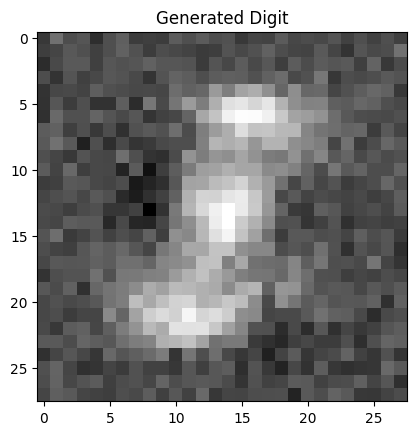

In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
transform = transforms.ToTensor()
dataset = torchvision.datasets.MNIST(root='./data', download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator()
D = Discriminator()

loss_fn = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)


for epoch in range(3):
    for real, _ in loader:
        real = real.view(-1, 784)


        z = torch.randn(real.size(0), 100)
        fake = G(z)

        loss_D = loss_fn(D(real), torch.ones(real.size(0),1)) + \
                 loss_fn(D(fake.detach()), torch.zeros(real.size(0),1))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        z = torch.randn(real.size(0), 100)
        fake = G(z)

        loss_G = loss_fn(D(fake), torch.ones(real.size(0),1))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch} Done")


z = torch.randn(1, 100)
generated = G(z).view(28,28).detach()

plt.imshow(generated, cmap='gray')
plt.title("Generated Digit")
plt.show()
